目的
* Pytorchによる **多層パーセプトロン(Multilayer Perceptron: MLP)** を用いてMNISTの画像分類を行う。
---
Objective
* Perform image classification on MNIST using **a Multilayer Perceptron (MLP)** in PyTorch.

| 比較     | MLP     | CNN     |
| ------ | ------- | ------- |
| 主な用途   | 表データ、数値 | 画像、動画   |
| 入力の扱い  | 1次元     | 2次元（画像） |
| 位置情報   |  失われる  | 保持    |
| パラメータ数 | 多い      | 少ない     |
| 画像認識   | 苦手      | 得意      |

準備
* Graphics Processing Unit (GPU)を用いて処理を行うために、上部のメニューバーの「ランタイム」→「ランタイムのタイプを変更」からハードウェアアクセラレータをGPUにしてください。
---
Preparation
* To perform processing using a Graphics Processing Unit (GPU), please go to the top menu bar, select "Runtime" → "Change runtime type", and set the Hardware accelerator to GPU.

In [ ]:
import numpy as np
import torch
import torch.nn as nn

import torchvision
import torchvision.transforms as transforms

import torchsummary

* 学習データ（MNIST Dataset）を読み込みます。
* Loading the training data (MNIST Dataset).

In [ ]:
train_data = torchvision.datasets.MNIST(root="./", train=True, transform=transforms.ToTensor(), download=True)
test_data = torchvision.datasets.MNIST(root="./", train=False, transform=transforms.ToTensor(), download=True)

### 読み込んだデータの情報を表示して確認/Display and check the information of the loaded data
# 画像・ラベルデータのデータタイプ（型）/Image and label data types
print(type(train_data.data), type(train_data.targets))
print(type(test_data.data), type(test_data.targets))
# 画像・ラベルの配列サイズ/Array size of images and labels
print(train_data.data.size(), train_data.targets.size())
print(test_data.data.size(), test_data.targets.size())

100%|██████████| 9.91M/9.91M [00:00<00:00, 11.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 346kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.19MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.6MB/s]


<class 'torch.Tensor'> <class 'torch.Tensor'>
<class 'torch.Tensor'> <class 'torch.Tensor'>
torch.Size([60000, 28, 28]) torch.Size([60000])
torch.Size([10000, 28, 28]) torch.Size([10000])


* MNISTデータセットに含まれる画像を表示します。
* Display the images contained in the MNIST dataset.

<Figure size 640x480 with 0 Axes>

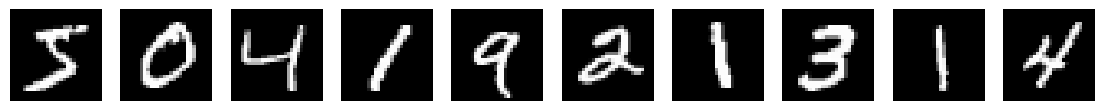

In [ ]:
import matplotlib.pyplot as plt   # グラフ表示用のモジュールをインポート/Import a module for displaying graphs

cols = 10  # 描画する数を指定/Specify the number to draw

plt.clf()
fig = plt.figure(figsize=(14, 1.4))  # 描画する図のサイズを指定（横: 14, 縦: 1.4）/Specify the size of the figure to be plotted (width: 14, height: 1.4)
for c in range(cols):
    ax = fig.add_subplot(1, cols, c + 1)
    ax.imshow(train_data[c][0].view(28, 28), cmap=plt.get_cmap('gray'))  # imshowでc番目の画像を描画/Display the c-th image using imshow
    ax.set_axis_off()  # 縦・横軸の表示をオフ/Hide the vertical and horizontal axes
plt.show()             # 表示/Display

* ニューラルネットワーク(全結合層2層から構成)を定義します。
* 入力層のユニット数は入力データのサイズによります。
ここでは`28 x 28 = 786`とし画像の画素値を**1次元配列**として並べ替えたデータを入力するように指定します。

  **__init__()メソッド**

  中間層と出力層のユニット数は引数として与えそれぞれ`n_hidden`，`n_out`とします。
  ネットワーククラスの定義では`__init__()`にこれらの引数を与えて各層を定義します。
  各層はLinear関数としています。これは全結合層を意味しています。
  また`self.act`で活性化関数を指定します。ここではシグモイド関数を活性化関数として指定します。※シグモイド関数（sigmoid function）とは、入力を 0〜1 の範囲に滑らかに変換する関数で、主に機械学習や統計で使われます。

  **forward()メソッド**

  `forward()`で定義した層を接続して処理するように記述します。
  `forward()`の引数`x`は入力データを示しています。
  それを`forward()`で定義した`l1`という中間層および活性化関数`act`へ順番に入力します。
  その出力を`h1`としています。
  `h1`は出力層`l2`に与えられその出力を`h2`としています。

---

* Define a neural network consisting of two fully connected layers.
* The number of units in the input layer depends on the size of the input data.
Here, we set it to 28 × 28 = 784 and specify that the image pixel values should be provided as **a one-dimensional array**.

  **__init__()method**

  The number of units in the hidden layer and the output layer are given as arguments, denoted as n_hidden and n_out, respectively.
  In the definition of the network class, these arguments are passed to __init__() to define each layer.
  Each layer is implemented as a Linear function, which means a fully connected layer.
  Also, the activation function is specified by self.act. Here, the sigmoid function is used as the activation function.
  Note: The sigmoid function is a function that smoothly maps its input to the range 0–1, and is mainly used in machine learning and statistics.

  **forward()method**

  In forward(), the layers defined are connected and processed.
  The argument x in forward() represents the input data.
  It is sequentially passed through the intermediate layer l1 and the activation function act defined in forward().
  The output of this is stored in h1.
  Then, h1 is fed into the output layer l2, and its output is stored in h2.

In [ ]:
class MLP(nn.Module):
    def __init__(self, n_hidden, n_out):
        super().__init__()
        self.l1 = nn.Linear(28*28, n_hidden)
        self.l2 = nn.Linear(n_hidden, n_out)
        self.act = nn.Sigmoid()

    def forward(self, x):
        h1 = self.act(self.l1(x))
        h2 = self.l2(h1)
        return h2

* 上のプログラムで定義したネットワークを作成します。
* 中間層と出力層のユニット数を定義します。
* 中間層のユニット数`hidden_num`を8、出力層のユニット数`out_num`をMNISTのクラス数に対応する10とします。
* 各層のユニット数を上で定義した`MLP`クラスの引数として与えネットワークモデルを定義します。
* 学習を行う際の最適化方法としてモーメンタムSGD(モーメンタム付き確率的勾配降下法）を利用します。学習率を0.01、モーメンタムを0.9として引数に与えます。
* 最後に定義したネットワークの詳細情報を`torchsummary.summary()`関数を用いて表示します。第一引数に詳細を表示したいモデル、第二引数にネットワークへ入力されるデータのサイズを指定します。これによって，ネットワークの構造を確認することができます。

---

* Creating the network as defined in the above program.
* Define the number of units for the hidden layer and the output layer.
* Set the number of units in the hidden layer, hidden_num, to 8, and the number of units in the output layer, out_num, to 10, corresponding to the number of classes in MNIST.
* Define the network model by passing the number of units for each layer as arguments to the previously defined MLP class.
* When performing training, we use Momentum SGD (stochastic gradient descent with momentum) as the optimization method. The learning rate is set to 0.01, and the momentum is set to 0.9, which are provided as arguments.
* The detailed information of the most recently defined network is displayed using the torchsummary.summary() function. The first argument specifies the model whose details you want to display, and the second argument specifies the size of the input data to the network. This allows you to check the structure of the network.

In [ ]:
# ユニット数の定義/Definition of the number of units
hidden_num = 8
out_num = 10

# ネットワークの作成/Create a network
model = MLP(n_hidden=hidden_num, n_out=out_num)

# 最適化手法の設定 lr: 学習率, momentum: モーメンタム (慣性項のパラメータ)/Optimizer settings: lr: learning rate, momentum: momentum (parameter of the inertia term)
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

# 定義したモデルの情報を表示/Display information of the defined model
torchsummary.summary(model, (1, 28*28), device='cpu')

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                 [-1, 1, 8]           6,280
           Sigmoid-2                 [-1, 1, 8]               0
            Linear-3                [-1, 1, 10]              90
Total params: 6,370
Trainable params: 6,370
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.02
Estimated Total Size (MB): 0.03
----------------------------------------------------------------


**学習**

MNISTデータセットと作成したネットワークを用いて学習を行います。

**パラメータの設定**

1回の誤差を算出するデータ数（ミニバッチサイズ）を100、学習エポック数を10とします。

**データローダーの定義**

データローダーでは上で読み込んだデータセット（`train_data`）を用いてfor文で指定したミニバッチサイズでデータを読み込むオブジェクトを作成します。
この時の引数は以下の通り

* batch_size：ミニバッチサイズ
* shuffle：読み込むデータをランダムに指定するかどうか (True/False)

**誤差関数**

分類問題をあつかうため、クロスエントロピー誤差を計算するための`CrossEntropyLoss`を`criterion`として定義します。

**ネットワークの動作モードの変更**

`model.train()`とすることでネットワークの演算を学習モードに設定します。
ネットワーク内にDropoutなどの学習と評価で動作が変わるモジュールがある場合に必要なものです。
今回のネットワークにはDropoutは含まれていませんが学習開始前には実行しておくことが望ましい。

**学習の実行**

各更新において、学習用データと教師データをそれぞれ`image`と`label`とします。
学習モデルにimageを与えて各クラスの確率yを取得します。
各クラスの確率yと教師ラベルtとの誤差を`criterion`で算出します。
また認識精度も算出します。そして誤差をbackward関数で逆伝播し、ネットワークの更新を行います。

---

**Learning**

Perform training using the MNIST dataset and the network we created.

**Parameter settings**

The number of data points used to calculate the error in one iteration (mini-batch size) is set to 100, and the number of training epochs is set to 10.

**Definition of the DataLoader**

In a DataLoader, we create an object that loads the dataset (e.g., train_data) in mini-batches of the size specified in a for loop.
The arguments for this are as follows:

* batch_size：mini-batch size
* shuffle：Whether to select the data to load randomly (True/False)

**Error function**

To handle a classification problem, we define CrossEntropyLoss as criterion to calculate the cross-entropy error.

**Change of network operating mode**

Setting model.train() puts the network in training mode.
This is necessary when the network contains modules such as Dropout that behave differently during training and evaluation.
Although the current network does not include Dropout, it is still recommended to execute this before starting training.

**Execution of learning**

For each update, we denote the training data and the target data as image and label, respectively.
We input image into the training model to obtain the probability y for each class.
The error between the class probabilities y and the target labels t is computed using the criterion.
We also calculate the recognition accuracy. Then, the error is backpropagated using the backward function, and the network is updated.

In [ ]:
# ミニバッチサイズ・エポック数の設定/Setting the mini-batch size and the number of epochs
batch_size = 100
epoch_num = 10

# データローダーの設定/Data Loader Settings
train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True)

# 誤差関数の設定/Setting of the error function
criterion = nn.CrossEntropyLoss()

# ネットワークを学習モードへ変更/Set the network to training mode
model.train()

# 学習の実行/Execution of learning
for epoch in range(1, epoch_num+1):   # epochのforループ/for each epoch in the training process
    # 1 epochの学習中の誤差・学習画像が正解した数をカウントする変数を初期化/Initialize variables to count the loss and the number of correctly classified training images during one epoch
    sum_loss = 0.0
    count = 0

    for image, label in train_loader:  # 1 epoch内のforループ (iterationのループ)/the for-loop within one epoch (loop over iterations)
        # 画像の画素値配列を [batch, channel, height, width] --> [batch, channel * height * width]に変更/Change the pixel array of the image
        image = image.view(image.size()[0], -1)

        y = model(image)  # 画像をネットワークへ入力して認識結果を出力/Input the image into the network and output the recognition result

        loss = criterion(y, label)  # 誤差計算/calculation of error
        model.zero_grad()           # ネットワークパラメータに対する勾配情報 (直前のbackpropagationの情報) を削除/Delete gradient information with respect to network parameters (from the most recent backpropagation)
        loss.backward()             # backpropagation
        optimizer.step()            # モデルのパラメータを更新/Update the model parameters

        # 学習経過を確認するための処理/Process to monitor training progress
        sum_loss += loss.item()            # 誤差の値を加算/Add the error value
        pred = torch.argmax(y, dim=1)      # ミニバッチ内のデータの予測結果 (最もスコアが高いクラス番号) を計算/Compute the predicted results for the data in a mini-batch (the class with the highest score)
        count += torch.sum(pred == label)  # 予測が正しい画像の数 (正解サンプル数) を加算/Add the number of correctly predicted images (number of correct samples)

    # 1 epoch終了時点での誤差の平均値，学習データに対する認識精度を表示/Display the average error at the end of one epoch and the recognition accuracy on the training data
    print("epoch:{}, mean loss: {}, mean accuracy: {}".format(epoch, sum_loss/600, count.item()/60000.))

epoch:1, mean loss: 1.6037652759750685, mean accuracy: 0.5914
epoch:2, mean loss: 0.8253827220201493, mean accuracy: 0.8073166666666667
epoch:3, mean loss: 0.5786232813696066, mean accuracy: 0.8610666666666666
epoch:4, mean loss: 0.4749183388054371, mean accuracy: 0.8806666666666667
epoch:5, mean loss: 0.4232561665276686, mean accuracy: 0.8892666666666666
epoch:6, mean loss: 0.39238963931798937, mean accuracy: 0.8953166666666666
epoch:7, mean loss: 0.3709064948062102, mean accuracy: 0.9002333333333333
epoch:8, mean loss: 0.3553100993484259, mean accuracy: 0.9033833333333333
epoch:9, mean loss: 0.34282623196641604, mean accuracy: 0.9057833333333334
epoch:10, mean loss: 0.3333886821816365, mean accuracy: 0.9085


**テスト**

学習したネットワークを用いてテストデータに対する認識率の確認を行います。

**ネットワークの動作モードの変更**

`model.eval()`を適用することでネットワーク演算を評価モードへ変更します。
これにより学習時と評価時で挙動が異なる演算（dropout等）を変更することが可能です。

**勾配情報を保持しない設定**

また`torch.no_grad()`を適用することで学習時には必要になる勾配情報を保持することなく演算を行います。これによりメモリの消費量を抑制したり推論速度の高速化が期待できます。

---

**test**

Use the trained network to evaluate the recognition rate on the test data.

**Change of network operating mode**

model.eval() sets the network to evaluation mode. This allows operations that behave differently during training and evaluation (such as dropout) to be adjusted accordingly.

**Setting to not retain gradient information**

By applying torch.no_grad(), computations are performed without retaining the gradient information required during training. This helps reduce memory usage and can improve inference speed.

In [ ]:
# データローダーの準備/Preparing the Data Loader
test_loader = torch.utils.data.DataLoader(test_data, batch_size=100, shuffle=False)

# ネットワークを評価モードへ変更/Change the network to evaluation mode
model.eval()

# 評価の実行/Performing evaluation
count = 0
with torch.no_grad():  # 勾配を計算しない設定にする (loss.backwardをしても勾配情報が計算されない)/Set it to not compute gradients (so that calling loss.backward() does not compute gradient information)
    for image, label in test_loader:
        image = image.view(image.size()[0], -1)
        y = model(image)

        pred = torch.argmax(y, dim=1)
        count += torch.sum(pred == label)

print("test accuracy: {}".format(count.item() / 10000.))

test accuracy: 0.9119


**課題**

#####ネットワークの構造を変更し認識精度の変化を確認しましょう。

**ヒント：ネットワーク構造の変更としては次のようなものが考えられます**
* 中間層のユニット数
* 層の数
* 活性化関数
  * `nn.Tanh()`、`nn.ReLU()`、`nn.LeakyReLU()`などが考えられます。
  * その他のPyTorchで使用できる活性化関数は[こちらページ](https://pytorch.org/docs/stable/nn.html#non-linear-activations-weighted-sum-nonlinearity)にまとめられています．

※ ネットワーク構造を変更した際には`torchsummary.summary()`関数を使用しネットワーク構造を変更した際のパラメータ数の変化を確認してみましょう。